In [2]:
import logging
logging.getLogger("deepspeed").setLevel(logging.WARNING)
logging.getLogger("transformers").setLevel(logging.WARNING)
logging.getLogger("datasets").setLevel(logging.WARNING)
from spec2selfies.models.invertion_model import InversionModel
from spec2selfies.models.config import InversionConfig
import spec2selfies
import importlib
from datasets import load_from_disk
import torch
from spec2selfies.models.model_utils import load_embedder_and_tokenizer
from transformers import AutoTokenizer
import random as rd
import torch.nn.functional as F
from tqdm import tqdm
import selfies as sf
import matplotlib.pyplot as plt
from rdkit import DataStructs
from rdkit.Chem import AllChem
from rdkit.Chem import rdMolDescriptors

[2025-08-27 12:49:21,376] [INFO] [real_accelerator.py:254:get_accelerator] Setting ds_accelerator to cuda (auto detect)


/usr/bin/ld: cannot find -laio
clang-15: error: linker command failed with exit code 1 (use -v to see invocation)
/usr/bin/ld: cannot find -laio
clang-15: error: linker command failed with exit code 1 (use -v to see invocation)


[2025-08-27 12:49:31,871] [INFO] [logging.py:107:log_dist] [Rank -1] [TorchCheckpointEngine] Initialized with serialization = False


In [ ]:
print (model.bottleneck_dim)

In [1]:
from datasets import load_from_disk

dataset = load_from_disk("./data/scaffold_split_merged_spectra/arrow/tokenized_datasets/with_formula/perfect_model/test")
print (dataset)

Dataset({
    features: ['selfies', 'spectre', 'input_ids', 'attention_mask', 'labels', 'length', 'embedder_input_ids', 'embedder_attention_mask', 'formula', 'model_spectra'],
    num_rows: 13892
})


In [4]:
from tqdm import tqdm

l = []
for i in tqdm(range(len(dataset))):
    mol = dataset[i]['selfies']
    mol = get_mol(mol)
    l.append(mol.GetNumHeavyAtoms())

100%|██████████| 13892/13892 [01:51<00:00, 124.86it/s]


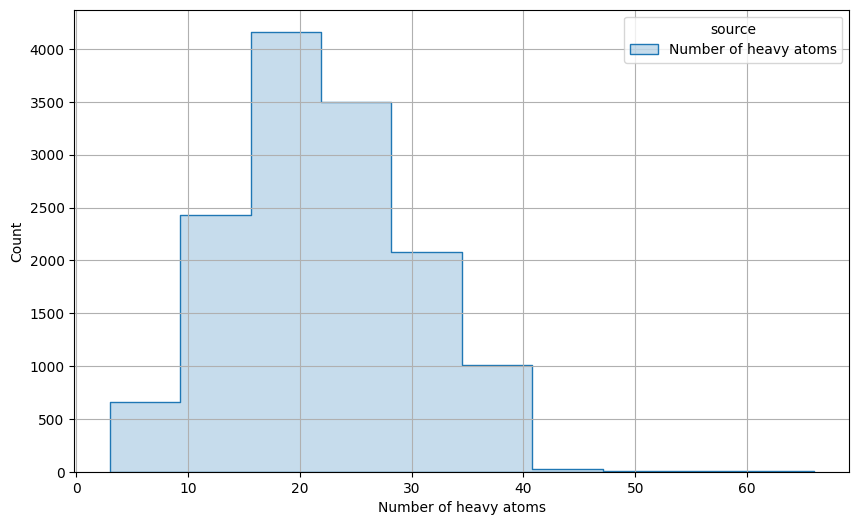

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

df = pd.DataFrame(l, columns=["Number of heavy atoms"])

df = df.melt(
    var_name="source", value_name="value"
)
plt.figure(figsize=(10, 6))
ax = sns.histplot(
    data=df,
    x="value",
    hue="source",
    bins=10,
    kde=False,
    element="step",  
    stat="count",  
    common_norm=False,
)
plt.xlabel("Number of heavy atoms")
plt.ylabel("Count")
plt.grid(True)

fig = ax.get_figure()   
fig.savefig("./data/eval/figures/Hist_heavy_atoms_test.png", dpi=300)

plt.show()

In [4]:
inputs = dataset[0]
inputs['hypothesis_attention_mask'] = inputs['attention_mask']
inputs['hypothesis_attention_mask'] = torch.tensor(inputs['hypothesis_attention_mask']).unsqueeze(0)
inputs['attention_mask'] = torch.tensor(inputs['attention_mask']).unsqueeze(0)
inputs['hypothesis_input_ids'] = torch.tensor(inputs['hypothesis_input_ids']).unsqueeze(0)
inputs['input_ids'] = torch.tensor(inputs['input_ids']).unsqueeze(0)
inputs['spectre'] = torch.tensor(inputs['spectre']).unsqueeze(0)
inputs['hypothesis_spectra'] = torch.tensor(inputs['hypothesis_spectra']).unsqueeze(0)
print (inputs['spectre'].shape)
model.generate(
    inputs= inputs,
    generation_kwargs={
        "max_length": 514,              
        "num_beams": 1,                                       
        "early_stopping": True,
        "num_return_sequences": 1      
    }
)

torch.Size([1, 1801])


/lustre/fshomisc/sup/hpe/pub/miniforge/24.9.0/envs/pytorch-gpu-2.6.0+py3.12.8/lib/python3.12/site-packages/transformers/generation/configuration_utils.py:679: UserWarning: `num_beams` is set to 1. However, `early_stopping` is set to `True` -- this flag is only used in beam-based generation modes. You should set `num_beams>1` or unset `early_stopping`.
  warnings.warn(


tensor([[2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0

In [21]:
embedder, embedder_tokenizer = load_embedder_and_tokenizer(
        'SELFormer',
        with_formula=True,
        ATOM_LIST=['I', 'C', 'S', 'N', 'Br', 'H', 'O', 'Si', 'Cl', 'P', 'F']
    )

In [13]:
t1 = torch.tensor([[1,2,3], [1,2,3]])
t2 = torch.tensor([[4, 5, 6],[4, 5, 6]])

t3 = torch.tensor([[7, 8,9], [4, 5, 6]])
t4 = torch.tensor([[10,11,12], [4, 5, 6]])
a= [t1, t2]
b= [t3, t4]
t = torch.cat(a + b, dim=1)
print(t)

tensor([[ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12],
        [ 1,  2,  3,  4,  5,  6,  4,  5,  6,  4,  5,  6]])


In [95]:
id = 2

print (f'PRED : {test_dt[id]['hypothesis_formula']}')
print (f'TRUE : {test_dt[id]['formula']}')
print (f'PRED : {test_dt[id]['hypothesis_selfies']}')
print (f'TRUE : {test_dt[id]['selfies']}')
loss = SIDLoss()
t1 = torch.tensor(test_dt[id]['hypothesis_formula']).to(dtype=torch.float).unsqueeze(0)
print (t1)
t2 = torch.tensor(test_dt[id]['formula']).to(dtype=torch.float).unsqueeze(0)
print (t2)
print (F.cosine_similarity(t1, t2, dim=1)[0])

PRED : [0, 15, 0, 3, 0, 0, 6, 0, 0, 0, 0]
TRUE : [0, 18, 0, 2, 1, 0, 4, 0, 0, 0, 0]
PRED : [C][C][O][C][=C][C][=C][Branch1][=Branch1][N+1][=Branch1][C][=O][O-1][C][=C][Ring1][=Branch2][N][C][=Branch1][C][=O][C][=C][C][=C][Branch1][=Branch1][N+1][=Branch1][C][=O][O-1][C][=C][Ring1][=Branch2]
TRUE : [C][C][=C][C][Branch1][=Branch1][N+1][=Branch1][C][=O][O-1][=C][C][=C][Ring1][=Branch2][N][C][=Branch1][C][=O][C][=C][C][=C][Branch1][Branch2][O][C][C][Branch1][C][C][C][C][Branch1][C][Br][=C][Ring1][N]
tensor([[ 0., 15.,  0.,  3.,  0.,  0.,  6.,  0.,  0.,  0.,  0.]])
tensor([[ 0., 18.,  0.,  2.,  1.,  0.,  4.,  0.,  0.,  0.,  0.]])
tensor(0.9829)


In [96]:
import numpy as np

c = 0
count = 0
cust_c = []
cos_c = [] 
one_c = 0
for i in tqdm(range(len(test_dt))):
    t1 = torch.tensor(test_dt[i]['hypothesis_formula']).to(dtype=torch.float)
    t2 = torch.tensor(test_dt[i]['formula']).to(dtype=torch.float)
    cust = torch.sum(torch.abs(t1 - t2)) / torch.sum(torch.max(t1, t2))
    c = F.cosine_similarity(t1.unsqueeze(0), t2.unsqueeze(0), dim=1)
    if c == 1:
        one_c += 1
    cust_c.append(cust)
    cos_c.append(c[0])

print (1-np.mean(cust_c))
print (np.std(cust_c))
print (np.mean(cos_c))
print (np.std(cos_c))
print (one_c)

100%|██████████| 117061/117061 [18:25<00:00, 105.85it/s]


0.6650455892086029
0.17473342
0.97961557
0.03843631
4627


In [82]:
t1 = torch.tensor([3, 4, 8, 2, 9, 1, 0, 12, 89])
t2 = torch.tensor([190 for _ in range(9)])
print (torch.sum(torch.abs(t1 - t2)))
print (torch.max(torch.sum(t1), torch.sum(t2)))
cust = torch.sum(torch.abs(t1 - t2)) / torch.max(torch.sum(t1), torch.sum(t2))
print (cust)

tensor(1582)
tensor(1710)
tensor(0.9251)


In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print (f"Device is {device}")
model = model.to(device)

generate_kwargs = {
    "max_length": 514,              
    "num_beams": 30,                                       
    "early_stopping": True,         
    "pad_token_id": tokenizer.pad_token_id,
    "eos_token_id": tokenizer.eos_token_id,
    "bos_token_id": tokenizer.bos_token_id,  
    "num_return_sequences": 1      
}

decoded_selfies = []
for i in tqdm(range(1)):
    _id = rd.randint(0, 10_000)
    _input = dataset[_id]
    print (_input['formula'])
    _input['spectre'] = torch.tensor(_input['spectre']).unsqueeze(0).to(device)
    #_input['formula'] = torch.tensor(_input['formula']).unsqueeze(0).to(device)
    true_selfies = _input['selfies']
    _input['embedder_input_ids'] = torch.tensor(_input['embedder_input_ids']).unsqueeze(0).to(device)
    _input['embedder_attention_mask'] = torch.tensor(_input['embedder_attention_mask']).unsqueeze(0).to(device)

    output = model.generate(_input, generate_kwargs)
    decoded = tokenizer.decode(output[0], skip_special_tokens=True)
    print(f"PRED : {decoded}")
    print("\n")
    print (f"TRUE : {true_selfies}")
    #print("\n")
    #print ('#######################')
    #print("\n")
    dico = {
        'true_spec' : _input['spectre'],
        'true_mol' : true_selfies,
        'pred_mol' : decoded, 
        'pred_spec' : get_spec([decoded], embedder, embedder_tokenizer)[0]
    }
    decoded_selfies.append(dico)

print ("Done")

Device is cuda


  0%|          | 0/1 [00:00<?, ?it/s]

[0, 15, 0, 2, 0, 0, 4, 0, 0, 0, 0]
PRED : [C][C][O][C][=Branch1][C][=O][C][=C][C][=C][Branch1][=Branch1][C][=Branch1][C][=O][O][C][=C][Ring1][Branch2]


TRUE : [C][C][=C][C][=C][C][Branch2][Ring1][=Branch2][O][C][=Branch1][C][=O][C][=C][Branch1][=Branch1][C][=Branch1][C][=O][O][C][=N][N][Ring1][Branch2][C][Branch1][C][C][C][=C][Ring2][Ring1][Ring2]
torch.Size([1, 512])


100%|██████████| 1/1 [00:05<00:00,  5.38s/it]

Done


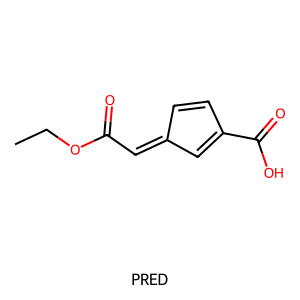

C10H10O4


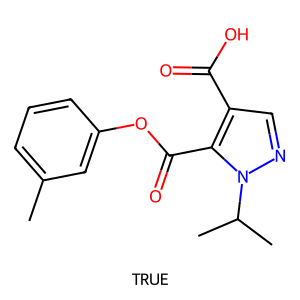

C15H16N2O4
{'tan': 0.11614730878186968, 'dice': 0.20812182741116753, 'cosine': 0.24691180045324074, 'sokal': 0.061654135338345864, 'russel': 0.06005859375, 'kul': 0.29293149095129295, 'mcCo': -0.41413701809741416}


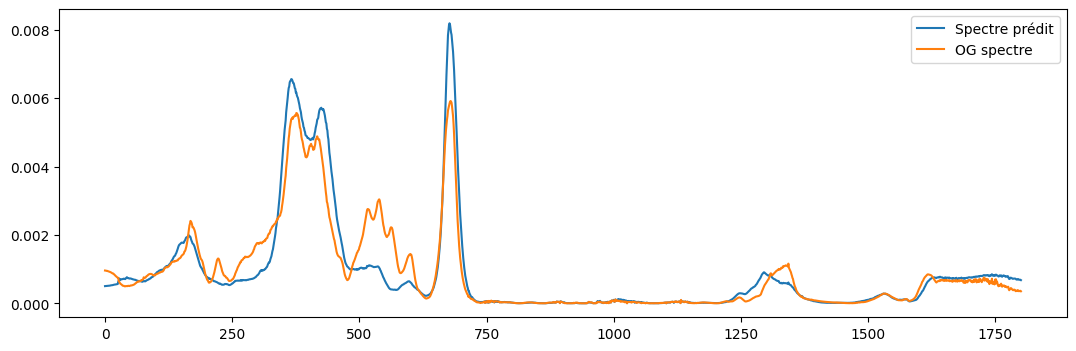

Done


In [23]:
# Pred
for i in range(len(decoded_selfies)):
    draw_mol(decoded_selfies[i].get('pred_mol'), 'PRED')
    selfies1 = decoded_selfies[i].get('pred_mol')
    mol1 = get_mol(selfies1)
    formula1 = rdMolDescriptors.CalcMolFormula(mol1)
    print (formula1)
    
    draw_mol(decoded_selfies[i].get('true_mol'), 'TRUE')
    selfies2 = decoded_selfies[i].get('true_mol')
    mol2 = get_mol(selfies2)
    formula2 = rdMolDescriptors.CalcMolFormula(mol2)
    print (formula2)
    
    dico = get_mol_similarities(selfies1, selfies2)
    print (dico)
    
    viz_spec(decoded_selfies[i].get('pred_spec'), decoded_selfies[i].get('true_spec'))
    
    

In [6]:
from scipy.ndimage import gaussian_filter1d
from icecream import ic
import torch.nn as nn
import torch
import numpy
import torch.nn.functional as F

class SIDLoss(nn.Module):

    def forward(self, model_spectra, target_spectra, conv=True, norm=True):
        
        target_spectra_conv = gaussian_filter1d(target_spectra, 5)                     
        model_spectra_conv = y.numpy() if not conv else gaussian_filter1d(model_spectra, 5)  
        temp = target_spectra_conv
        
        if norm:
            target_spectra_conv = nn.functional.normalize(torch.tensor(target_spectra_conv), p=1)  
            model_spectra_conv = nn.functional.normalize(torch.tensor(model_spectra_conv), p=1)
        else: # back to torch (not optimal)
            target_spectra_conv = torch.from_numpy(target_spectra_conv)
            model_spectra_conv = torch.from_numpy(model_spectra_conv)

        loss = torch.ones_like(target_spectra)

        loss = torch.mul(torch.log(torch.div(model_spectra, target_spectra)), model_spectra) \
                + torch.mul(torch.log(torch.div(target_spectra, model_spectra)), target_spectra)
        
        loss = torch.sum(loss, dim=-1)
        
        loss = 1/(1+loss)
        
        return loss


def gaussian_filter1d_torch(x, sigma, dim=-1):
    if sigma == 0:
        return x

    radius = int(4 * sigma)
    kernel_size = 2 * radius + 1

    coords = torch.arange(kernel_size, device=x.device) - radius
    kernel = torch.exp(-0.5 * (coords / sigma) ** 2)
    kernel = kernel / kernel.sum()  # normalize

    kernel = kernel.view(1, 1, -1)

    # Reshape input if needed (e.g., (B, C, L))
    needs_perm = dim != -1
    if needs_perm:
        x = x.transpose(dim, -1)

    x = F.conv1d(
        x.unsqueeze(1),  # add channel dimension
        kernel,
        padding=radius,
        groups=1,
    ).squeeze(1)

    if needs_perm:
        x = x.transpose(dim, -1)

    return x


In [15]:
config = InversionConfig.from_pretrained(
            "./data/saved_models/Inverter__30epochs__encoder_decoder_frozen/checkpoint-15411"
        )

config.store_embedder = False
config.with_sep = True
config.with_formula = False
config.ATOM_LIST = []
config.embedder_dim = 1801
config.bottleneck_dim = 1801
config.formula_dim = 11

model = InversionModel.from_pretrained(
    "./data/saved_models/Inverter__30epochs__encoder_decoder_frozen/checkpoint-15411",
    config=config
)
tokenizer = AutoTokenizer.from_pretrained("./data/saved_models/Inverter__30epochs__encoder_decoder_frozen/checkpoint-15411")

Some weights of InversionModel were not initialized from the model checkpoint at ./data/saved_models/Inverter__30epochs__encoder_decoder_frozen/checkpoint-15411 and are newly initialized: ['formula_transform.0.bias', 'formula_transform.0.weight', 'formula_transform.3.bias', 'formula_transform.3.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [13]:
import torch
from safetensors.torch import load_file, save_file


# Load the state dict from the safetensors file
state_dict_fouled = set(load_file("./data/saved_models/Inverter__30epochs__encoder_decoder_frozen/checkpoint-15411/model.safetensors"))
state_dict_sound = set(model.state_dict().keys())


list_fouled = list(state_dict_fouled)
list_sound = list(state_dict_sound)



In [14]:
keys = list(state_dict_fouled - state_dict_sound)
print (f"Unexpected keys : {len(keys)}")
print ([k for k in keys if 'transform' in k])
print ("\n")
keys = (state_dict_sound - state_dict_fouled)
print (f"Missing keys : {len(keys)}")
print (keys)
print ("\n")
keys = (state_dict_sound & state_dict_fouled)
print (f"Common keys : {len(keys)}")
print (keys)

Unexpected keys : 0
[]


Missing keys : 214
{'embedder.roberta.encoder.layer.8.attention.output.LayerNorm.bias', 'embedder.roberta.encoder.layer.10.attention.output.dense.weight', 'embedder.roberta.encoder.layer.9.attention.self.value.weight', 'embedder.roberta.encoder.layer.6.attention.self.query.weight', 'embedder.roberta.encoder.layer.1.output.dense.bias', 'embedder.roberta.encoder.layer.10.attention.self.query.bias', 'embedder.roberta.encoder.layer.2.attention.self.query.weight', 'embedder.roberta.encoder.layer.11.intermediate.dense.weight', 'embedder.roberta.encoder.layer.11.attention.self.value.bias', 'embedder.roberta.encoder.layer.7.attention.output.LayerNorm.weight', 'embedder.roberta.encoder.layer.1.output.LayerNorm.bias', 'embedder.roberta.embeddings.LayerNorm.weight', 'embedder.roberta.encoder.layer.5.attention.output.dense.bias', 'embedder.roberta.encoder.layer.8.intermediate.dense.bias', 'embedder.roberta.encoder.layer.0.intermediate.dense.bias', 'embedder.roberta.encoder

In [3]:
import torch
from safetensors.torch import load_file, save_file
weights = load_file("./data/saved_models/Corrector__30epoch__lora/model.safetensors")

In [4]:
new_weights = {}
for name, tensor in weights.items():
    new_name = name
    if "transform" in name:
        new_name = name.replace("transform_", "transform")
    new_weights[new_name] = tensor

save_file(new_weights, "./data/saved_models/Corrector__30epoch__lora/model.safetensors")

In [18]:
print (len(list_fouled))
print (len(list_sound))

list_fouled.sort()
list_sound.sort()

for i in range(685):
    print (f"{list_fouled[i]} -- {list_sound[i]}")
    print ("\n")



877
685
embedder.classifier.layers.0.bias -- embedding_transform1.0.bias


embedder.classifier.layers.0.weight -- embedding_transform1.0.weight


embedder.classifier.layers.3.bias -- embedding_transform1.3.bias


embedder.classifier.layers.3.weight -- embedding_transform1.3.weight


embedder.classifier.layers.6.bias -- embedding_transform2.0.bias


embedder.classifier.layers.6.weight -- embedding_transform2.0.weight


embedder.classifier.out_proj.bias -- embedding_transform2.3.bias


embedder.classifier.out_proj.weight -- embedding_transform2.3.weight


embedder.roberta.embeddings.LayerNorm.bias -- embedding_transform3.0.bias


embedder.roberta.embeddings.LayerNorm.weight -- embedding_transform3.0.weight


embedder.roberta.embeddings.position_embeddings.weight -- embedding_transform3.3.bias


embedder.roberta.embeddings.token_type_embeddings.weight -- embedding_transform3.3.weight


embedder.roberta.embeddings.word_embeddings.weight -- encoder_decoder.base_model.model.final_logits_bias

In [1]:
import matplotlib.pyplot as plt
from rdkit import Chem
import selfies as sf
from rdkit.Chem import Draw, AllChem, rdMolDescriptors, DataStructs
from rdkit.Chem import rdFingerprintGenerator
import numpy as np
from matplotlib.offsetbox import OffsetImage, AnnotationBbox


def draw_mol(selfies: str, label: str):
    smiles = sf.decoder(selfies)
    mol = Chem.MolFromSmiles(smiles)
    img = Draw.MolToImage(mol, legend=label)
    display(img)
    return img

def get_mol(selfies):
    smiles = sf.decoder(selfies)
    mol = Chem.MolFromSmiles(smiles)

    return mol

def viz_spec(pred, label, no_pred=False, no_label=False, mol_img=None):
    fig, ax = plt.subplots(figsize=(14,5))
    
    pred = pred.flatten().tolist()
    label = label.flatten().tolist()

    x = [i for i in range(len(pred))]

    if mol_img is not None:
        mol_arr = np.array(mol_img)
        imagebox = OffsetImage(mol_arr, zoom=0.6)
        ab = AnnotationBbox(imagebox, (0.6, 0.65),
                            xycoords='axes fraction',
                            frameon=False, 
                            box_alignment=(0.5,0.5)
                           )
        ax.add_artist(ab)

    if not no_pred:
        ax.plot(x, pred, label='Predicted spectrum')
    if not no_label:
        ax.plot(x, label, label='Target spectrum')

    plt.legend()
    plt.show()
    return fig

def get_spec(selfies: str, embedder, embedder_tokenizer):
    encoding = embedder_tokenizer(
            selfies,
            padding='max_length',
            truncation=True,
            max_length=512,
            return_tensors="pt",
        )
    input_ids = encoding['input_ids'].to(embedder.device)
    attention_mask = encoding['attention_mask'].to(embedder.device)
    print (input_ids.shape)
    pred_spec = embedder(input_ids, attention_mask, selfies)
    
    return pred_spec

def get_mol_similarities(mol1, mol2):
    mol1 = sf.decoder(mol1)
    mol2 = sf.decoder(mol2)
    mol1 = Chem.MolFromSmiles(mol1)
    mol2 = Chem.MolFromSmiles(mol2)
    fpgen = rdFingerprintGenerator.GetRDKitFPGenerator(fpSize=2048)
    fps1 = fpgen.GetFingerprint(mol1)
    fps2 = fpgen.GetFingerprint(mol2)
    tan = DataStructs.TanimotoSimilarity(fps1,fps2)
    dice = DataStructs.DiceSimilarity(fps1,fps2)
    cosine = DataStructs.CosineSimilarity(fps1,fps2)
    sokal = DataStructs.SokalSimilarity(fps1,fps2)
    russel = DataStructs.RusselSimilarity(fps1,fps2)
    kul = DataStructs.KulczynskiSimilarity(fps1,fps2)
    mcCo = DataStructs.McConnaugheySimilarity(fps1,fps2)
    dico = {
        'tan' : tan,
        'dice': dice,
        'cosine': cosine,
        'sokal': sokal,
        'russel': russel,
        'kul': kul,
        'mcCo': mcCo,
    }
    return dico

In [2]:
import importlib
import spec2selfies
from icecream import ic
from datasets import load_from_disk
corrector = spec2selfies.load_pretrained_corrector("SELFormer_WithFormula")
dataset = load_from_disk("./data/scaffold_split_merged_spectra/arrow/tokenized_datasets/with_formula/perfect_model/test")

[2025-08-27 14:21:38,758] [INFO] [real_accelerator.py:254:get_accelerator] Setting ds_accelerator to cuda (auto detect)


/usr/bin/ld: cannot find -laio
clang-15: error: linker command failed with exit code 1 (use -v to see invocation)
/usr/bin/ld: cannot find -laio
clang-15: error: linker command failed with exit code 1 (use -v to see invocation)


[2025-08-27 14:21:50,503] [INFO] [logging.py:107:log_dist] [Rank -1] [TorchCheckpointEngine] Initialized with serialization = False
torch.float32


wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.


WANDB_STARTUP_DEBUG 1756297331.6794522 launch
WANDB_STARTUP_DEBUG 1756297331.6844378 wait_ports
WANDB_STARTUP_DEBUG 1756297332.8857493 wait_ports_done
WANDB_STARTUP_DEBUG 1756297332.8864217 launch_done


In [3]:
print (dataset)

Dataset({
    features: ['selfies', 'spectre', 'input_ids', 'attention_mask', 'labels', 'length', 'embedder_input_ids', 'embedder_attention_mask', 'formula', 'model_spectra'],
    num_rows: 13892
})


In [4]:
perfect_match = [366, 385, 392, 395, 597, 598, 599, 661, 671, 947, 948, 954, 967, 1003, 1012, 1013, 1037, 1044, 1083, 1122, 1132, 1134, 1151, 1164, 1173, 1188, 1191, 1192, 1201, 1205, 1210, 1222, 1239, 1255, 1257, 1270, 1271, 1276, 1280, 1282, 1292, 1298, 1300, 1319, 1323, 1333, 1347, 1362, 1364, 1371, 1379, 1393, 1396, 1441, 1445, 1471, 1480, 1483, 1500, 1518, 1522, 1526, 1532, 1537, 1541, 1543, 1564, 1566, 1578, 1591, 1600, 1605, 1627, 1635, 1658, 1667, 1673, 1687, 1691, 1703, 1744, 1746, 1747, 1757, 1760, 1769, 1772, 1775, 1800, 1808, 1809, 1810, 1815, 1816, 1825, 1829, 1845, 1852, 1853, 1857, 1868, 1884, 1885, 1887, 1898, 1944, 2002, 2019, 2024, 2097, 2351, 2354, 2356, 2368, 2373, 2397, 2407, 2412, 2418, 2422, 2427, 2428, 2437, 2439, 2450, 2466, 2470, 2475, 2481, 2500, 2510, 2517, 2521, 2543, 2545, 2552, 2555, 2557, 2574, 2579, 2585, 2601, 2610, 2613, 2627, 2628, 2629, 2632, 2633, 2644, 2645, 2656, 2670, 2673, 2678, 2679, 2686, 2689, 2693, 2695, 2702, 2780, 2910, 2918, 2921, 2934, 2948, 2949, 2956, 2968, 2974, 2976, 2985, 2990, 2992, 3001, 3002, 3005, 3012, 3070, 3112, 3116, 3504, 3643, 3645, 3650, 3652, 3659, 3663, 3666, 3684, 3699, 3702, 3707, 3715, 3717, 3718, 3721, 3722, 3723, 3737, 3741, 3817, 3825, 3833, 3834, 3843, 3848, 3856, 3862, 3866, 3870, 3871, 3879, 3883, 3885, 3888, 3899, 3962, 3963, 3964, 3965, 3969, 3976, 3977, 3980, 3981, 3984, 3988, 3989, 3990, 4005, 4009, 4011, 4015, 4022, 4032, 4036, 4037, 4180, 4190, 4199, 4202, 4205, 4210, 4211, 4216, 4229, 4233, 4235, 4256, 4261, 4265, 4268, 4275, 4277, 4282, 4284, 4287, 4290, 4292, 4294, 4300, 4301, 4442, 4566, 4574, 4579, 4581, 4591, 4593, 4594, 4595, 4601, 4613, 4622, 4752, 5509, 5609, 5620, 5625, 5630, 5631, 5636, 5640, 5648, 5732, 5735, 5739, 5745, 5754, 5762, 5766, 5823, 5824, 5825, 5831, 5837, 5839, 5843, 5846, 5848, 5853, 5855, 5858, 6071, 6401, 6403, 6405, 6409, 6411, 6413, 6416, 6602, 6605, 6846, 6852, 6856, 6865, 6868, 6930, 6937, 6946, 7142, 7214, 7321, 7323, 7326, 7328, 7330, 7331, 7335, 7338, 7339, 7340, 7341, 7343, 7459, 7464, 7465, 7468, 7469, 7470, 7472, 7473, 7478, 7482, 7487, 7488, 7489, 7491, 7492, 7494, 7498, 8844, 8863, 8870, 8873, 9075, 9076, 9077, 9139, 9149, 9425, 9426, 9432, 9445, 9481, 9490, 9491, 9515, 9522, 9561, 9600, 9610, 9612, 9629, 9642, 9651, 9666, 9669, 9670, 9679, 9683, 9688, 9700, 9717, 9733, 9735, 9748, 9749, 9754, 9758, 9760, 9770, 9776, 9778, 9797, 9801, 9811, 9825, 9840, 9842, 9849, 9857, 9871, 9874, 9919, 9923, 9949, 9958, 9961, 9978, 9996, 10000, 10004, 10010, 10015, 10019, 10021, 10042, 10044, 10056, 10069, 10078, 10083, 10105, 10113, 10136, 10145, 10151, 10165, 10169, 10181, 10222, 10224, 10225, 10235, 10238, 10247, 10250, 10253, 10278, 10286, 10287, 10288, 10293, 10294, 10303, 10307, 10323, 10330, 10331, 10335, 10346, 10362, 10363, 10365, 10376, 10422, 10480, 10497, 10502, 10575, 10829, 10832, 10834, 10846, 10851, 10875, 10885, 10890, 10896, 10900, 10905, 10906, 10915, 10917, 10928, 10944, 10948, 10953, 10959, 10978, 10988, 10995, 10999, 11021, 11023, 11030, 11033, 11035, 11052, 11057, 11063, 11079, 11088, 11091, 11105, 11106, 11107, 11110, 11111, 11122, 11123, 11134, 11148, 11151, 11156, 11157, 11164, 11167, 11171, 11173, 11180, 11551, 11570, 11577, 11580, 11782, 11783, 11784, 11846, 11856, 12132, 12133, 12139, 12152, 12188, 12197, 12198, 12222, 12229, 12268, 12307, 12317, 12319, 12336, 12349, 12358, 12373, 12376, 12377, 12386, 12390, 12395, 12407, 12424, 12440, 12442, 12455, 12456, 12461, 12465, 12467, 12477, 12483, 12485, 12504, 12508, 12518, 12532, 12547, 12549, 12556, 12564, 12578, 12581, 12626, 12630, 12656, 12665, 12668, 12685, 12703, 12707, 12711, 12717, 12722, 12726, 12728, 12749, 12751, 12763, 12776, 12785, 12790, 12812, 12820, 12843, 12852, 12858, 12872, 12876, 12888, 12929, 12931, 12932, 12942, 12945, 12954, 12957, 12960, 12985, 12993, 12994, 12995, 13000, 13001, 13010, 13014, 13030, 13037, 13038, 13042, 13053, 13069, 13070, 13072, 13083, 13129, 13187, 13204, 13209, 13282, 13536, 13539, 13541, 13553, 13558, 13582, 13592, 13597, 13603, 13607, 13612, 13613, 13622, 13624, 13635, 13651, 13655, 13660, 13666, 13685, 13695, 13702, 13706, 13728, 13730, 13737, 13740, 13742, 13759, 13764, 13770, 13786, 13795, 13798, 13812, 13813, 13814, 13817, 13818, 13829, 13830, 13841, 13855, 13858, 13863, 13864, 13871, 13874, 13878, 13880, 13887]

In [127]:
import random as rd
import torch

id = rd.randint(0, len(perfect_match))
id = perfect_match[id]
_input = dataset[id: id+1]
selfies = _input.get("selfies")
spec_true = torch.tensor(_input.get("model_spectra")).to("cuda")
print (id)
print (spec_true.shape)
print(id in perfect_match)

13069
torch.Size([1, 1801])
True


In [128]:
gen_kwargs = {
            "max_length": 514,                              
            "num_beams": 10,
            "early_stopping": True,
            ######################
            "do_sample": False,    
            "num_return_sequences": 1      
        }
ic.disable()
ic.configureOutput(includeContext=True)

if len(spec_true.shape) < 2:
    spec_true = spec_true.unsqueeze(0)

print (spec_true.shape)
pred = spec2selfies.invert_embeddings(
    spec_true,
    corrector=corrector,
    gen_kwargs=gen_kwargs,
    num_steps=3,
    sequence_beam_width=15,
    with_formula=True,
    selfies=selfies,
    alpha=1
)
    
print (f"[PRED] : {pred[0]}")
print (f"[TRUE] : {selfies[0]}")

torch.Size([1, 1801])
[PRED] : [C][O][C][=Branch1][C][=O][C][=C][C][=C][C][=N][Ring1][=Branch1]
[TRUE] : [C][O][C][=Branch1][C][=O][C][=C][C][=C][C][=N][Ring1][=Branch1]


[PRED] : [C][O][C][=Branch1][C][=O][C][=C][C][=C][C][=N][Ring1][=Branch1]
[TRUE] : [C][O][C][=Branch1][C][=O][C][=C][C][=C][C][=N][Ring1][=Branch1]


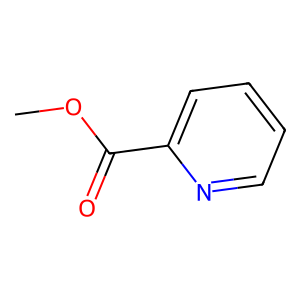

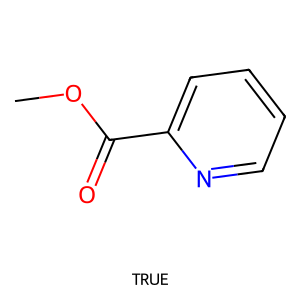

torch.Size([1, 512])


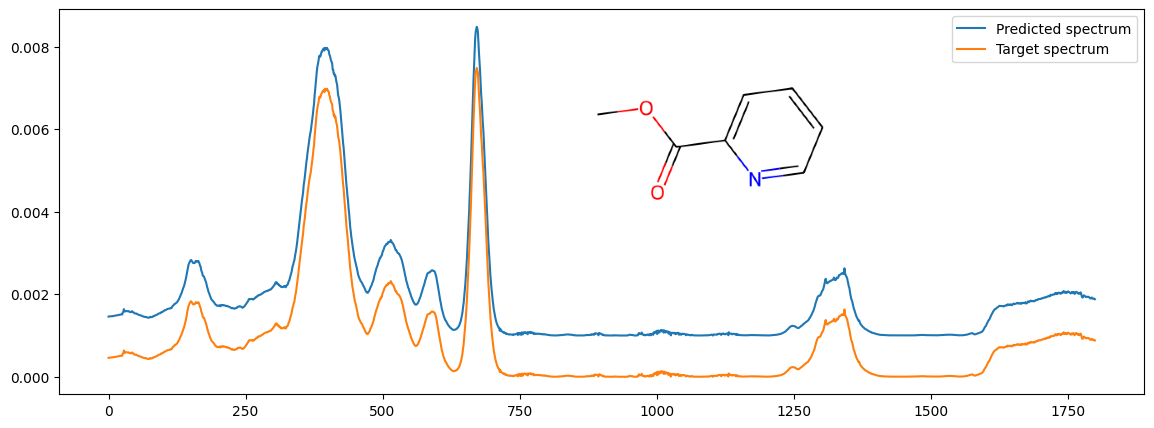

tensor([0.1979], device='cuda:0')
{'tan': 1.0, 'dice': 1.0, 'cosine': 1.0, 'sokal': 1.0, 'russel': 0.11328125, 'kul': 1.0, 'mcCo': 1.0}


In [131]:
i = 0

print (f"[PRED] : {pred[i]}")
print (f"[TRUE] : {selfies[0]}")
id_in_batch = 0
img = draw_mol(pred[i], "")
if type(selfies) == str:
    draw_mol(selfies, "TRUE")
else :
    draw_mol(selfies[id_in_batch], "TRUE")
spec_pred, _, _ = get_spec([pred[i]], corrector.embedder, corrector.embedder_tokenizer)
spec_pred += 0.001
fig = viz_spec(spec_pred, spec_true[id_in_batch], mol_img=img)
sim_fn = corrector.get_sim_fn()
print (sim_fn(spec_pred, spec_true[id_in_batch].unsqueeze(0)))
print (get_mol_similarities(pred[i], selfies[0]))
fig.savefig(f"./data/eval/figures/PM_example_perfect_pred_{id}.png", dpi=300)

In [70]:
B = 13000
N = 105
gamma = 2
r_min = 1300
_lambda = 0.4
increment = (B - r_min) / math.floor(math.log(N, gamma))

n = []
r = []
i = 0
while N > 1:
    _r = _lambda * (r_min + i*increment) + (1-_lambda) * (B/N)
    r.append(_r)
    n.append(N)
    N = math.floor(N/gamma) if math.floor(N/gamma) >= 1 else 1
    i+=1

n.append(N)
r.append(B)

x = [i for i in range(len(n))]
print (sum(n[i]*r[i] for i in range(len(n)))/13000)

print(f"nb configs : {n}")
print (f"budget par config : {r}")
plt.plot(x, n, label='nombre de config')
plt.legend()
plt.show()

plt.plot(x, r, label='budget max par config')
plt.legend()
plt.show()

NameError: name 'math' is not defined

In [1]:
from datasets import load_from_disk
dataset = load_from_disk("./data/scaffold_split_merged_spectra/arrow/hypothesis_dataset/train")

In [2]:
print(dataset)

Dataset({
    features: ['selfies', 'spectre', 'input_ids', 'attention_mask', 'labels', 'length', 'embedder_input_ids', 'embedder_attention_mask', 'hypothesis_input_ids', 'hypothesis_selfies', 'hypothesis_spectra'],
    num_rows: 117061
})


In [3]:
from tqdm import tqdm
import numpy as np

sizes = []
for item in tqdm(dataset):
    sizes.append(len(item['input_ids']))

print (f"Mean : {np.mean(sizes)}")
print (f"Std : {np.std(sizes)}")
print (f"Max : {np.max(sizes)}")
print (f"Min : {np.min(sizes)}")


100%|██████████| 117061/117061 [13:41<00:00, 142.55it/s]

Mean : 34.043866018571514
Std : 15.310083105801882
Max : 159
Min : 3


50.0
29.154759474226502


In [14]:
from torch.nn.utils.rnn import pad_sequence
import torch

"""
We have a list of size steps, with tensors of shape (batch, beam, signal)
We add a tensor of shape (batch, beam, max_length) to pad everything to max_length
"""
max_length = 4
batch = 2
beam = 2
signal = 3
l = [
    torch.ones(batch, beam, max_length),
    torch.rand(batch, 3),
    torch.rand(batch, beam, signal),
    torch.rand(batch, beam, signal),
    torch.rand(batch, beam, signal),
    torch.rand(batch, beam, signal),
    torch.rand(batch, beam, signal),
    torch.rand(batch, beam, signal),
    torch.rand(batch, beam, signal),
]

print (l[1])
l[1] = l[1].unsqueeze(1).expand(-1, beam, -1)
"""
We get all the infos we need for further reshape
"""
steps = len(l)
batch, beam, _ = l[0].shape

"""
We flatten because pad_sequence only works with 1D or 2D
"""
for i, _l in enumerate(l):
    l[i] = _l.reshape(batch*beam, -1)
all_signals = [sig for step in l for sig in step]

"""
We reshape and remove the dummy max_length tensor
"""
padded = pad_sequence(all_signals, batch_first=True, padding_value=0)
padded = padded.reshape(steps, batch, beam, -1).permute(1, 0, 2, 3)
padded = padded[:, 1:]

bm_text_ids = padded[:, 0, 0,:]
padded = padded[:, 1:]

print (padded.shape)

tensor([[0.4053, 0.3168, 0.6834],
        [0.3322, 0.0766, 0.5123]])
torch.Size([2, 7, 2, 4])


In [44]:
import torch
import random as rd

beam = 10 
steps = 5
batch = 16
l = [torch.rand(batch, beam) for _ in range(steps)]
a = rd.randint(0, steps-1)
b = rd.randint(0, batch-1)
c = rd.randint(0, beam-1)
print (l[a][b, c])

t = torch.cat(l, dim=1).reshape(batch, steps, beam)
print (t.shape)
print (t[b, a, c])
print (f"step : {a}, batch : {b}, beam : {c}")

tensor(0.1253)
torch.Size([16, 5, 10])
tensor(0.1253)
step : 1, batch : 12, beam : 3


In [60]:
from box import Box

def recurse_box(d: Box, prefix=""):
    for key, value in d.items():
        full_key = f"{prefix}.{key}" if prefix else key
        if isinstance(value, Box):
            yield from recurse_box(value, full_key)
        else:
            yield full_key, value

# Example
mybox = Box({"a": {"b": {"c": 1}}, "d": 2})
for path, val in recurse_box(mybox):
    print(path, "=", val)


a.b.c = 1
d = 2


In [75]:
from datasets import load_from_disk
dataset = load_from_disk("./data/scaffold_split_merged_spectra/arrow/tokenized_datasets/test")
print (dataset)
print (type(dataset))
dataset = dataset.select(range(10))
dataset.set_format(type="torch")
print (type(dataset))

Dataset({
    features: ['selfies', 'spectre', 'input_ids', 'attention_mask', 'labels', 'length', 'embedder_input_ids', 'embedder_attention_mask'],
    num_rows: 13892
})
<class 'datasets.arrow_dataset.Dataset'>
<class 'datasets.arrow_dataset.Dataset'>


In [7]:
import torch

t = torch.rand((4, 3, 3))
print (t)
t = t[:, 2,:].max(dim=1).values
print (t.shape)
print (t)

tensor([[[0.1419, 0.9978, 0.5545],
         [0.2412, 0.0574, 0.2391],
         [0.1857, 0.1434, 0.4059]],

        [[0.1239, 0.7370, 0.6359],
         [0.4069, 0.0132, 0.4249],
         [0.0382, 0.3490, 0.0529]],

        [[0.1702, 0.3332, 0.7529],
         [0.1210, 0.3447, 0.4699],
         [0.9743, 0.7031, 0.3008]],

        [[0.8237, 0.3183, 0.0914],
         [0.9563, 0.2662, 0.3614],
         [0.7051, 0.8782, 0.8629]]])
torch.Size([4])
tensor([0.4059, 0.3490, 0.9743, 0.8782])


In [1]:
from spec2selfies.eval_utils import load_logs

wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.


WANDB_STARTUP_DEBUG 1751272177.8224595 launch
WANDB_STARTUP_DEBUG 1751272177.82578 wait_ports
WANDB_STARTUP_DEBUG 1751272178.6266003 wait_ports_done
WANDB_STARTUP_DEBUG 1751272178.6271024 launch_done


In [19]:
t = load_logs('/lustre/fsn1/projects/rech/aik/unh74gq/cache/vec2text/eval/purely-clean-skink/text_ids')

In [1]:
l = [i for i in range(514)]
print (len(l[:-2]))

512
